### Part 1: Data Exploration and Preprocessing
Task:1.1 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_data.csv")
df.head(10)

,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0
5,CUST000249,36.0,Female,Tier 2,Silver,160.15,6,26.69,39.0,8.0,3,8.96,0
6,CUST003299,32.0,Male,Tier 2,Gold,3440.79,17,202.40,29.0,29.0,6,304.40,1
7,CUST000107,37.0,Female,Tier 1,Silver,505.17,6,84.20,51.0,15.0,4,16.93,0
8,CUST000280,26.0,Female,Tier 3,Silver,2476.96,9,275.22,44.0,10.0,4,71.01,0
9,CUST001282,27.0,NaN,Tier 1,Silver,404.24,12,33.69,56.0,17.0,8,26.07,0


In [3]:
df.shape

(5025, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   object 
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   object 
 3   city_tier                     5025 non-null   object 
 4   membership_type               5025 non-null   object 
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_value_customer           5025 non-null   int64  
dtypes: 

In [5]:
df.describe()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.000000,5025.000000,5025.000000,5025.000000,4723.000000,4724.000000,5025.000000,5025.000000,5025.000000
mean,39.279483,3520.270324,15.047761,219.407385,29.456490,23.032599,6.714030,308.958681,0.373731
std,11.608329,3503.705187,7.628706,167.171094,13.163085,10.362527,3.162972,373.824281,0.483842
min,18.000000,11.590000,1.000000,1.770000,4.000000,3.000000,1.000000,0.430000,0.000000
25%,30.000000,1031.970000,9.000000,99.830000,19.000000,15.000000,4.000000,61.530000,0.000000
50%,38.000000,2258.380000,14.000000,176.020000,26.000000,21.000000,6.000000,166.820000,0.000000
75%,47.000000,4777.600000,20.000000,291.620000,41.000000,30.000000,9.000000,405.600000,1.000000
max,75.000000,27621.780000,43.000000,1500.110000,69.000000,59.000000,15.000000,3999.660000,1.000000


Task:1.2

In [6]:
df.isnull().sum()

customer_id                       0
age                             302
gender                          301
city_tier                         0
membership_type                   0
total_spend                       0
num_transactions                  0
avg_transaction_value             0
days_since_last_purchase        302
num_visits                      301
product_categories_purchased      0
discount_used                     0
high_value_customer               0
dtype: int64

In [7]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [8]:
for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

C:\Users\paulm\AppData\Local\Temp\ipykernel_11740\3626972091.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)
C:\Users\paulm\AppData\Local\Temp\ipykernel_11740\3626972091.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [9]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\paulm\AppData\Local\Temp\ipykernel_11740\1626528281.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [10]:
df.isnull().sum()

customer_id                     0
age                             0
gender                          0
city_tier                       0
membership_type                 0
total_spend                     0
num_transactions                0
avg_transaction_value           0
days_since_last_purchase        0
num_visits                      0
product_categories_purchased    0
discount_used                   0
high_value_customer             0
dtype: int64

Task 1.3

In [11]:
df.duplicated(subset="customer_id").sum()

np.int64(25)

In [12]:
df.drop_duplicates(subset="customer_id",inplace=True)

In [13]:
df.shape

(5000, 13)

25 duplicate records were identified based on customer_id and were removed from the dataset.

Task:1.4

In [14]:
df['gender'].value_counts()

gender
Female    2639
Male      2292
Other       69
Name: count, dtype: int64

In [15]:
df['membership_type'].value_counts()

membership_type
Silver      1959
Gold        1911
Platinum    1130
Name: count, dtype: int64

In [16]:
df['high_value_customer'].value_counts()

high_value_customer
0    3129
1    1871
Name: count, dtype: int64

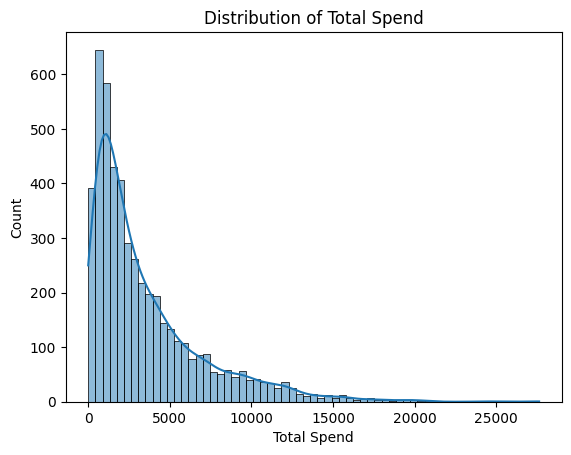

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['total_spend'],kde = True)
plt.title("Distribution of Total Spend")
plt.xlabel("Total Spend")
plt.ylabel("Count")
plt.show()

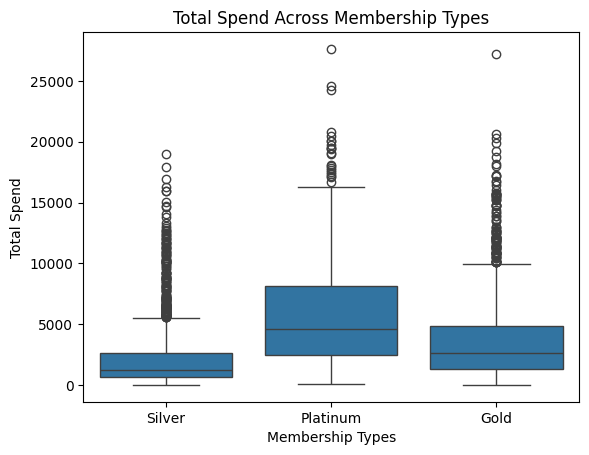

In [18]:
sns.boxplot(x='membership_type',y='total_spend',data=df)
plt.title("Total Spend Across Membership Types")
plt.xlabel("Membership Types")
plt.ylabel("Total Spend")
plt.show()

### Observations

1. The total spend distribution is right-skewed, with most customers spending moderate amounts and a few customers spending significantly higher amounts.
2. Platinum members have the highest median total spend, followed by Gold and Silver members.
3. High-value customers appear as outliers across all membership types, indicating potential premium customer segments.

### Part 2: Customer Segmentation using Clustering
Task:2.1

In [19]:
features = df[['age', 'total_spend','num_transactions','avg_transaction_value','days_since_last_purchase','num_visits']]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


### Why Scaling is Necessary

Scaling is necessary before clustering because K-means uses distance calculations. 
Features with larger ranges (like total_spend) can dominate the clustering process if data is not normalized.
Standard scaling ensures that all features contribute equally.

Task:2.2

In [21]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2,9):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

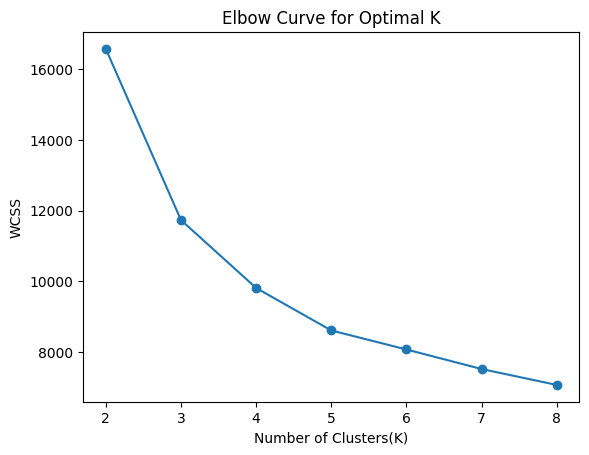

In [22]:
plt.plot(range(2,9),wcss,marker='o')
plt.title("Elbow Curve for Optimal K")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.show()

### Optimal Number of Clusters

The elbow curve shows a significant decrease in WCSS up to K = 3, after which the rate of decrease becomes gradual.
This indicates diminishing returns beyond three clusters, so K = 3 was selected as the optimal number of clusters.

Task:2.3

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [24]:
df['customer_segment'] = clusters

In [25]:
df['customer_segment'].value_counts()

customer_segment
0    2103
1    1754
2    1143
Name: count, dtype: int64

In [26]:
df.groupby('customer_segment')[[
    'age',
    'total_spend',
    'num_transactions',
    'avg_transaction_value',
    'days_since_last_purchase',
    'num_visits'
]].mean()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits
customer_segment,,,,,,
0,41.879696,2930.655882,15.315264,206.586567,24.162625,23.278650
1,28.529647,1002.440644,7.969213,145.877919,43.842075,13.559293
2,50.657918,8470.500490,25.358705,356.350761,16.231846,36.528434


### Customer Segment Profiles

Customer Segment 0 consists of older customers who make fewer purchases and visit less frequently, with a long gap since their last purchase. 
Although they have relatively higher average transaction values, their low engagement and infrequent activity indicate dormant or low-value customers.

Customer Segment 1 represents younger customers with moderate total spending but the lowest transaction frequency and average transaction value.
These customers show limited engagement and may represent occasional or exploratory buyers.

Customer Segment 2 includes highly valuable and loyal customers who have the highest total spend, transaction frequency, and visit count.
They purchase frequently, spend more per transaction, and have the shortest time since last purchase, making them the most engaged and profitable segment.

### Part 3: Predictive Modeling
Task:3.1

In [27]:
df['spend_per_visit'] = df['total_spend']/df['num_visits']
df['discount_percentage'] = df['discount_used']/df['total_spend']

### Feature Engineering Explanation

The feature spend_per_visit captures how much a customer spends on average per visit, helping identify high-value customers beyond total spend.
The discount_percentage feature indicates how dependent a customer is on discounts, which can influence profitability and customer targeting strategies.

Task:3.2

In [28]:
X = df.drop(columns=['high_value_customer','customer_id'])
y = df['high_value_customer']

In [29]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)

Numerical columns: ['age', 'total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits', 'product_categories_purchased', 'discount_used', 'spend_per_visit', 'discount_percentage']
Categorical columns: ['gender', 'city_tier', 'membership_type']


In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [31]:
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

In [33]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

In [34]:
import numpy as np
X_train_final = np.hstack([X_train_num_scaled,X_train_cat_encoded])
X_test_finale = np.hstack([X_test_num_scaled,X_test_cat_encoded])

Task:3.3

In [35]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

In [36]:
log_reg.fit(X_train_final,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
y_pred = log_reg.predict(X_test_finale)

### Model Justification:
Logistic Regression was chosen because it is simple, interpretable, and performs well for binary classification problems. It works efficiently with scaled numerical features and one-hot encoded categorical variables, making it suitable for predicting high-value customers.

Task:3.4

In [38]:
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [39]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[602,  12],
       [ 19, 367]])

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

accuracy, precision, recall, f1

(0.969, 0.9683377308707124, 0.9507772020725389, 0.9594771241830066)

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       614
           1       0.97      0.95      0.96       386

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



The model demonstrates strong performance with high accuracy, precision, and F1-score, indicating reliable classification of customers.
Recall is the most important metric for this business problem because failing to identify a high-value customer could result in missed revenue opportunities.
With a recall of around 95%, the model effectively captures most high-value customers while maintaining minimal false positives.

### Part 4: Model Optimization and Business Insights
Task: 4.1

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

In [43]:
log_reg = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

In [44]:
param_grid = {
    'C':[0.01,0.1,1,10],
    'penalty':['l1','l2']
}

In [45]:
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    error_score='raise'
)

In [46]:
grid_search.fit(X_train_final,y_train)

c:\Users\paulm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paulm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

In [47]:
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'C': 1, 'penalty': 'l1'}


In [48]:
best_model = grid_search.best_estimator_

In [49]:
y_test_pred_tuned = best_model.predict(X_test_finale)

In [50]:
tuned_accuracy = accuracy_score(y_test,y_test_pred_tuned)
tuned_f1 = f1_score(y_test,y_test_pred_tuned)

print("Tuned Model Accuracy:",tuned_accuracy)
print("Tuned Model F1-score:",tuned_f1)

Tuned Model Accuracy: 0.977
Tuned Model F1-score: 0.970013037809648


In [51]:
comparison_df = pd.DataFrame({
    "Model":["Logistic Regression (Before Tuning)","Logistic Regression (After Tuning)"],
    "Accuracy":[0.96,tuned_accuracy],
    "F1-score":[0.96,tuned_f1]
})

comparison_df

,Model,Accuracy,F1-score
0,Logistic Regression (Before Tuning),0.960,0.960000
1,Logistic Regression (After Tuning),0.977,0.970013


Task:4.2

In [52]:
coefficients = best_model.coef_[0]

In [53]:
num_features = num_cols
cat_features = encoder.get_feature_names_out(cat_cols)
all_features = np.concatenate([num_features,cat_features])

In [54]:
feature_importance = pd.DataFrame({
    "Feature":all_features,
    "Coefficient":coefficients
})

In [55]:
feature_importance["abs_coef"] = feature_importance["Coefficient"].abs()
feature_importance_sorted = feature_importance.sort_values(
    by= "abs_coef",ascending=False
)

In [56]:
top_8_features = feature_importance_sorted.head(8)
top_8_features

,Feature,Coefficient,abs_coef
1,total_spend,27.396204,27.396204
8,spend_per_visit,-5.374992,5.374992
3,avg_transaction_value,-3.906440,3.906440
2,num_transactions,-1.430001,1.430001
5,num_visits,-1.413940,1.413940
6,product_categories_purchased,0.401063,0.401063
11,gender_Male,0.264961,0.264961
9,discount_percentage,-0.173336,0.173336


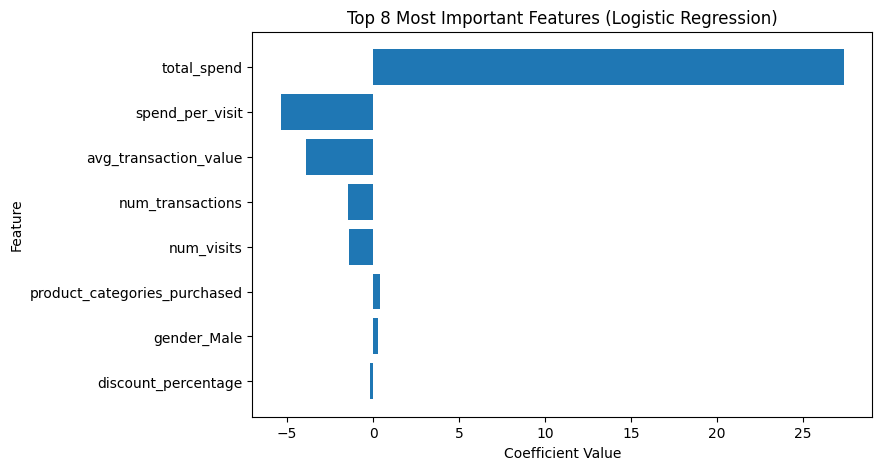

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_8_features["Feature"], top_8_features["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 8 Most Important Features (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

The feature importance analysis using logistic regression coefficients shows that customer spending-related variables such as total spend, average transaction value, and spend per visit have the strongest influence on churn prediction. Features with higher absolute coefficient values (abs_coef) impact the model more significantly, regardless of whether their effect is positive or negative. This indicates that customer purchasing behavior plays a more critical role in churn than demographic features.

Task:4.3

### Recommendation 1 (from feature importance)
Customers with lower total spend, average transaction value, and spend per visit show a higher likelihood of churn. The business should introduce personalized offers such as targeted discounts or loyalty rewards for low-spending customers to increase their purchase value and engagement.
### Recommendation 2 (from model predictions)
The churn prediction model can be used to proactively identify high-risk customers before they leave. These customers should be prioritized for retention campaigns such as personalized communication, exclusive deals, or early access to offers to reduce churn probability.
### Recommendation 3 (from clustering insights)
Customer segmentation reveals distinct behavioral groups based on spending and visit frequency. The business should design cluster-specific strategies—for example, rewarding high-value frequent customers with premium benefits while encouraging low-frequency customers through re-engagement campaigns.